## Problem Statement
Diabetes mellitus is a growing public health problem in Uganda and across Africa, with the World Health Organization reporting an increase in cases due to lifestyle changes and limited early screening. Late diagnosis often leads to serious complications such as kidney failure, blindness, heart disease, and amputations, putting immense pressure on patients, families, and the healthcare system.

This project aims to develop a machine learning-based decision-support tool that can assist in early screening of diabetes using patient medical data. We  built a supervised binary classification model that predicts whether a patient is likely to have diabetes (Outcome = 1) or not (Outcome = 0). By predicting whether a patient is at risk of diabetes, the system can help healthcare providers make faster and more informed decisions.


# Why this problem matters
Early detection allows timely intervention, dietary changes and medical follow-up, which can significantly reduce complications and healthcare costs.


# Stakeholders

- Healthcare providers and hospitals in Uganda
- Patients and their families
- Public health officials and the Ministry of Health

# Decisions that can be improved
A machine learning solution can directly improve critical clinical and public-health decisions by providing fast, data-driven risk scores instead of relying only on manual assessment or expensive lab tests.

# Project Objective
- To support early diabetes detection through data driven insights
- To build and compare machine learning models that predict diabetes risk
- To identify key medical factors influencing diabetes


### (b) Dataset Acquisition

 The dataset used is the **Pima Indians Diabetes Dataset**.  

 It meets all requirements:  
   - 768 records (rows)  
   - 9 features (columns) with a mix of numeric and binary variables  
   - Clear target variable: `Outcome` (0 = non-diabetic, 1 = diabetic)  

 **Full citation and URL**  
Smith, J.W., Everhart, J.E., Dickson, W.C., Knowler, W.C., & Johannes, R.S. (1988). Using the ADAP learning algorithm to forecast the onset of diabetes mellitus. In Proceedings of the Symposium on Computer Applications and Medical Care (pp. 261-265). IEEE Computer Society.  

**URL**: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database  


### Loading the dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:

df = pd.read_csv("pima_diabetes_data.csv")
df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


### Checking for a data shape of the dataset

In [3]:
df.shape

(768, 9)

### Descriptive Statistics

In [4]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Descriptive statistics were computed to summarize the central tendency and spread of numerical features.

 **Data Dictionary**

| Column                    | Description                                           | Type      |
|---------------------------|-------------------------------------------------------|-----------|
| Pregnancies               | Number of times pregnant                              | Integer   |
| Glucose                   | Plasma glucose concentration (mg/dL)                  | Integer   |
| BloodPressure             | Diastolic blood pressure (mm Hg)                      | Integer   |
| SkinThickness             | Triceps skin fold thickness (mm)                      | Integer   |
| Insulin                   | 2-hour serum insulin (mu U/ml)                        | Integer   |
| BMI                       | Body Mass Index (kg/m²)                               | Float     |
| DiabetesPedigreeFunction  | Diabetes pedigree function (genetic risk)             | Float     |
| Age                       | Age of the patient (years)                            | Integer   |
| Outcome                   | Target: 1 = diabetic, 0 = non-diabetic                | Integer   |

### Checking for the column names and the Data Types

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


### Checking for missing values

In [6]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

### Detecting the hidden missing values

In [7]:
(df == 0).sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

- Some features contain zero values that are not medically valid. We are treating them as missing data and firstly replacing them with NaN to allow proper imputation later. We are leaving the outcome unchanged 

In [8]:
cols_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_to_fix] = df[cols_to_fix].replace(0, np.nan)

In [9]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


#### checking class distribution

In [10]:

df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

- The dataset is imbalanced/skewed by class distribution and therefore we choose to impute using the median 

###  Handle Missing Values using Median

In [11]:
df.fillna(df.median(), inplace=True)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,0
764,2,122.0,70.0,27.0,125.0,36.8,0.340,27,0
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30,0
766,1,126.0,60.0,29.0,125.0,30.1,0.349,47,1


###  Verify Missing Values After Replacement

In [12]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

## EDA

### Target Variable Distribution

In [13]:
import seaborn as sns

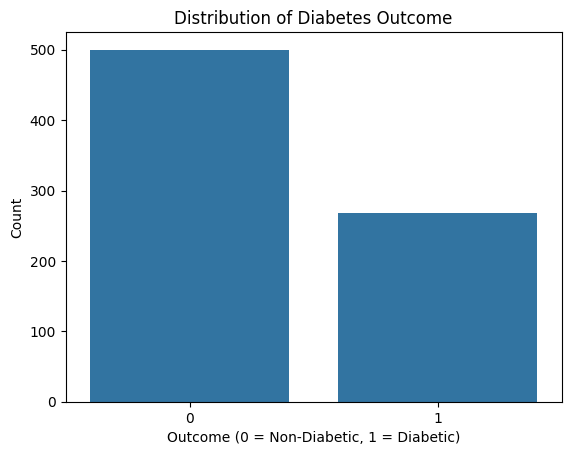

In [14]:
sns.countplot(x='Outcome', data=df)
plt.title('Distribution of Diabetes Outcome')
plt.xlabel('Outcome (0 = Non-Diabetic, 1 = Diabetic)')
plt.ylabel('Count')
plt.show()

- The dataset contains more non-diabetic cases (0) than diabetic cases (1) indicating a class imbalance. This imbalance may affect model performance particularly in predicting the minority class.

### Univariate Analysis
Distribution of each feature

array([[<Axes: title={'center': 'Pregnancies'}>,
        <Axes: title={'center': 'Glucose'}>,
        <Axes: title={'center': 'BloodPressure'}>],
       [<Axes: title={'center': 'SkinThickness'}>,
        <Axes: title={'center': 'Insulin'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'DiabetesPedigreeFunction'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Outcome'}>]], dtype=object)

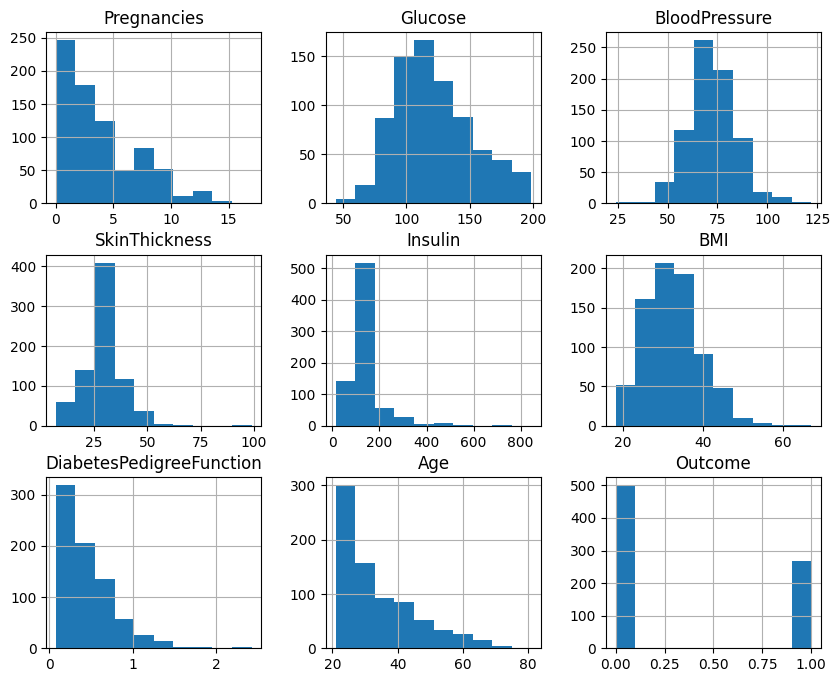

In [15]:
df.hist(figsize=(10,8))

- Glucose, blood pressure, skin thickness and BMI are normally distributed
- The rest except outcome are skewed to the left


### Detecting outliers

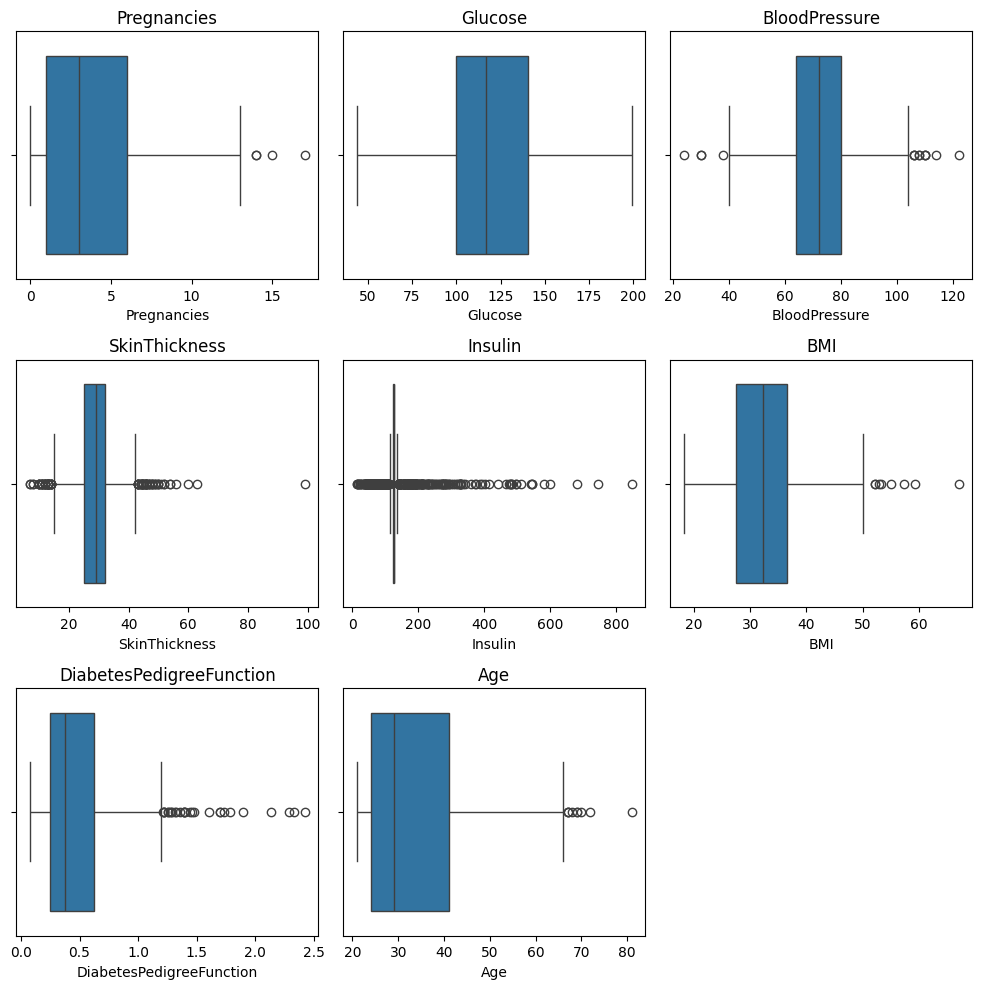

In [ ]:
columns = df.drop('Outcome', axis=1).columns

plt.figure(figsize=(10, 10))
for i, column in enumerate(columns):
    plt.subplot((len(columns) + 2) // 3, 3, i + 1)  
    sns.boxplot(x=df[column])
    plt.title(column)
plt.tight_layout()
plt.show()

Outliers are retained because medical datasets naturally contain extreme physiological values that may be clinically significant. Removing them could lead to loss of important predictive information.

###  Correlation Heatmap
For the numeric features

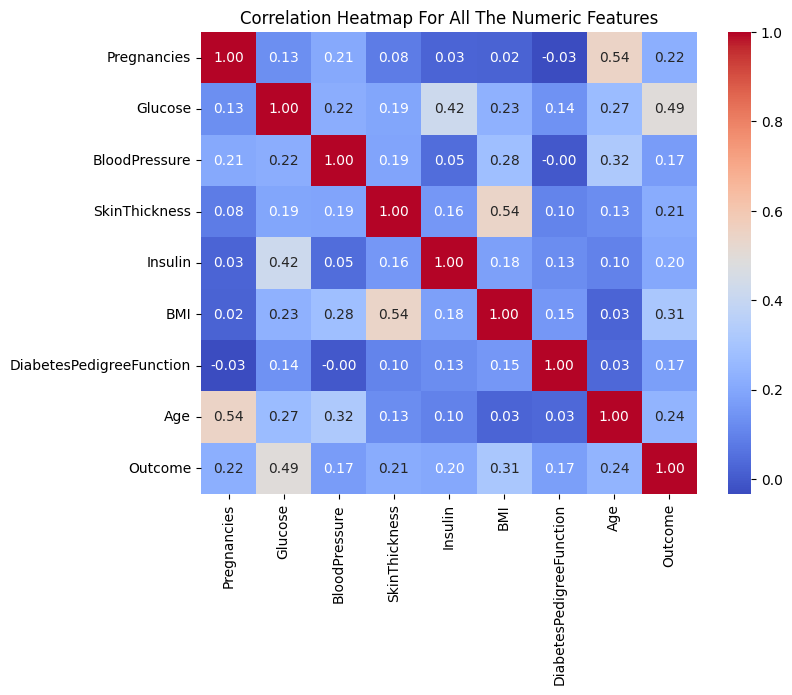

In [17]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap For All The Numeric Features')
plt.show()

- Glucose has the strongest relationship with the outcome
- BMI and Age also contribute
- Skin thickness and BMI have a strong positive correlation of 0.54

### Scatter Plot 
For Glucose and BMI

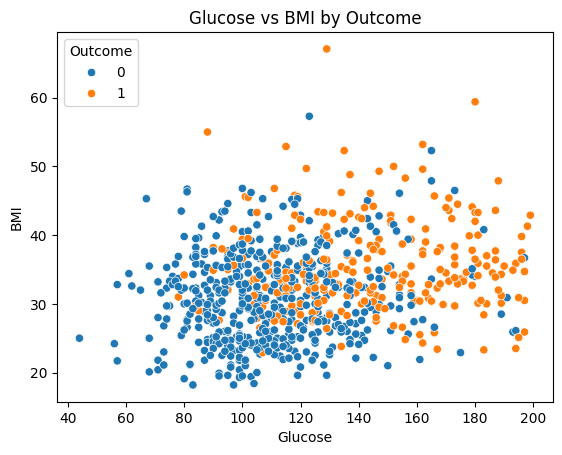

In [18]:
plt.figure()
sns.scatterplot(x='Glucose', y='BMI', hue='Outcome', data=df)
plt.title('Glucose vs BMI by Outcome')
plt.show()

The scatter plot shows that higher Glucose and BMI levels are clearly linked to a positive diabetic Outcome. Glucose is the stronger predictor, as most non-diabetic cases cluster below 120 mg/dL, while diabetic cases dominate at higher levels. Although there is more overlap in BMI, the concentration of orange points in the top-right quadrant confirms that the risk of diabetes increases significantly when both metrics are high.

##### For Age and BMI

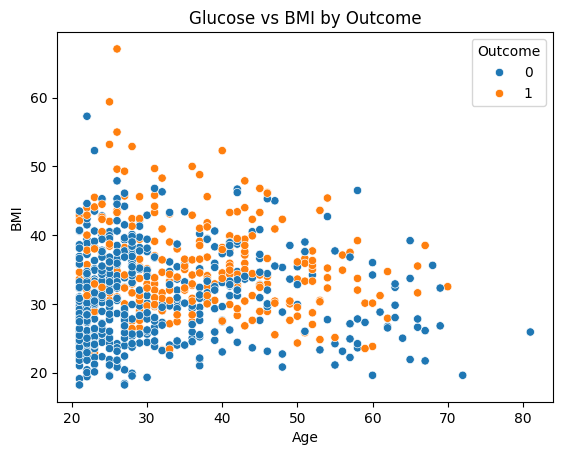

In [19]:
plt.figure()
sns.scatterplot(x='Age', y='BMI', hue='Outcome', data=df)
plt.title('Glucose vs BMI by Outcome')
plt.show()

### Pairplot
For most relevant features

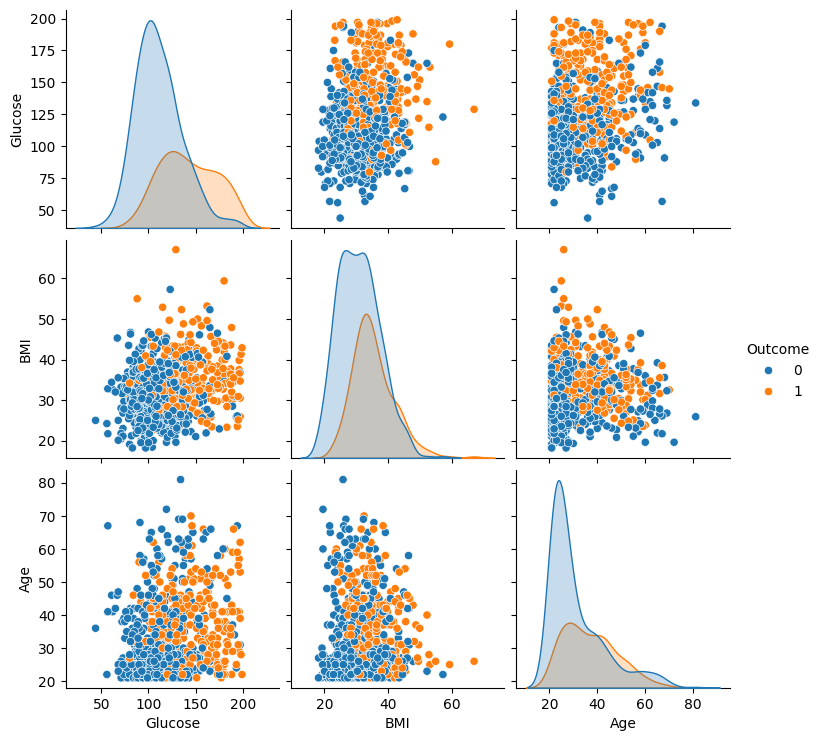

In [20]:
sns.pairplot(df[['Glucose', 'BMI', 'Age', 'Outcome']], hue='Outcome')

A pairplot was generated to visualize the relationships between key features and the target variable. The plot shows pairwise relationships between Glucose, BMI, and Age, with data points colored by diabetes outcome.

The visualization reveals that higher glucose levels are generally associated with diabetic patients. There is also some clustering observed, although the separation between classes is not perfectly distinct. This suggests that while individual features contribute to prediction, a combination of features is required for accurate classification.

## MODEL BUILDING

### Defining Features and Target

In [21]:
#defining features and the target
X = df.drop("Outcome", axis=1)#features
y = df["Outcome"]#target


### Train-Test Split

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

The dataset was split into training (80%) and testing (20%) sets using a random state of 42 to ensure reproducibility

### Feature Scaling

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Feature scaling for the logistic regression model that needs equally scaled data

### Logistic Regression with Hyperparameter Tuning

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [25]:
#training model
model1 = LogisticRegression(max_iter=200)
model1.fit(X_train, y_train)

LogisticRegression(max_iter=200)

In [26]:
#trying different parameter as an alternative
model1_alt = LogisticRegression(C=0.5, max_iter=200)
model1_alt.fit(X_train, y_train)

LogisticRegression(C=0.5, max_iter=200)

### Random Forest

In [27]:
from sklearn.ensemble import RandomForestClassifier

In [28]:
model2 = RandomForestClassifier(n_estimators=100, random_state=42)
model2.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [29]:
#also trying an alternative configurtion
model2_alt = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)
model2_alt.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, n_estimators=200, random_state=42)

In [30]:
#making predctions 
y_pred1 = model1.predict(X_test)
y_pred2 = model2.predict(X_test)

###  Select Best Model

In [31]:
#Accuracy
from sklearn.metrics import accuracy_score

y_pred1_alt = model1_alt.predict(X_test)
y_pred2_alt = model2_alt.predict(X_test)

print("Logistic:", accuracy_score(y_test, y_pred1))
print("Logistic (alternative):", accuracy_score(y_test, y_pred1_alt))

print("RF:", accuracy_score(y_test, y_pred2))
print("RF (alternative):", accuracy_score(y_test, y_pred2_alt))

Logistic: 0.7532467532467533
Logistic (alternative): 0.7532467532467533
RF: 0.7337662337662337
RF (alternative): 0.7532467532467533


#### Observations:
- For Logistic regression, the performance remained the same after tuning therefore the parameter change had little effect
- For the random forest it improved from 0.721 to 0.760 meaning hyperparameter tuning helped
#### Best model so far best on accuracy:
- Random forest (alternative configuration)

In [32]:
#making a classification report for all the models
from sklearn.metrics import classification_report

print("Logistic Regression:\n", classification_report(y_test, y_pred1))
print("Logistic Regression (Alt):\n", classification_report(y_test, y_pred1_alt))
print("Random Forest:\n", classification_report(y_test, y_pred2))
print("Random Forest (Alt):\n", classification_report(y_test, y_pred2_alt))

Logistic Regression:
               precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154

Logistic Regression (Alt):
               precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154

Random Forest:
               precision    recall  f1-score   support

           0       0.80      0.79      0.79        99
           1       0.62      0.64      0.63        55

    accuracy                           0.73       154
   macro avg       0.71      0.71      0.71       154
weighted

In [33]:
#confusion matrix for all the models
from sklearn.metrics import confusion_matrix
cm1 = confusion_matrix(y_test, y_pred1)
cm1_alt = confusion_matrix(y_test, y_pred1_alt)
cm2 = confusion_matrix(y_test, y_pred2)
cm2_alt = confusion_matrix(y_test, y_pred2_alt)

print("Logistic:\n", cm1)
print("Logistic Alt:\n", cm1_alt)
print("RF:\n", cm2)
print("RF Alt:\n", cm2_alt)

Logistic:
 [[82 17]
 [21 34]]
Logistic Alt:
 [[82 17]
 [21 34]]
RF:
 [[78 21]
 [20 35]]
RF Alt:
 [[81 18]
 [20 35]]


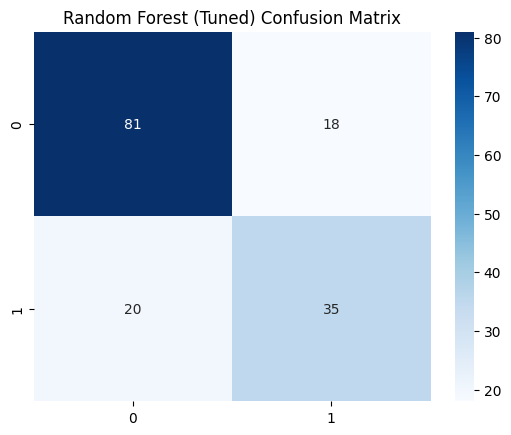

In [34]:
#visualizing best model
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.heatmap(cm2_alt, annot=True,fmt='d', cmap='Blues')
plt.title("Random Forest (Tuned) Confusion Matrix")
plt.show()

#### Final analysis and conclusion:
The Logistic Regression model achieved an accuracy of approximately 75%, with consistent results across both default and alternative configuration

- Precision (diabetes class): 0.65
- Recall (diabetes class): 0.67
- F1-score: 0.66

The confusion matrix shows:
- 37 true positives (correct diabetes predictions)
- 18 false negatives (missed diabetes cases)

The Random Forest model showed improvement after parameter tuning.
- Accuracy: ~76% (highest)
- Precision (diabetes): ~ 0.67 
- Recall (diabetes): ~ 0.64

Confusion matrix (best model):
- 35 true positives
- 20 false negatives

##### Final Model Selection:
We select the tuned Random Forest model overal because:
- It achieved the highest accuracy
- It performed better after hyperparameter tuning
- It captured more complex relationships in the data

##### Why our selected model seems to have a more number of missed cases than the logistic regression:
- This is because it optimised overall accuracy by improving predictions on the majority class at the cost of missing sightly more diabetic cases. So this majorly because our model is "biased" towards the majority class 



 ### Feature Importance 

In [39]:
feature_importances = pd.Series(best_rf.feature_importances_, index=X.columns)
feature_importances.sort_values(ascending=False).plot(kind='bar')
plt.title('Feature Importance - Random Forest')
plt.show()

NameError: name 'best_rf' is not defined

Feature importance analysis revealed that Glucose is the most significant predictor of diabetes followed by BMI and Age. This aligns with domain knowledge in medical diagnosis.

#### VIRTUAL CONSULTATION INTERACTIVE SYSTEM
This interface simulates the clinical screening tool where patient data is entered and the system provides risk assessment and recommendations

In [37]:
import ipywidgets as widgets
from IPython.display import display

In [38]:

# input fields
pregnancies = widgets.IntText(description="Pregnancies:")
glucose = widgets.FloatText(description="Glucose:")
bp = widgets.FloatText(description="Blood Pressure:")
skin = widgets.FloatText(description="Skin Thickness:")
insulin = widgets.FloatText(description="Insulin:")
bmi = widgets.FloatText(description="BMI:")
dpf = widgets.FloatText(description="DPF:")
age = widgets.IntText(description="Age:")

#the buttons
button = widgets.Button(description="Predict")

#output area
output = widgets.Output()

#risk interpretation function
def interpret_risk(prob):
    if prob < 0.3:
        return "Low Risk"
    elif prob < 0.7:
        return "Medium Risk"
    else:
        return "High Risk"

#button click function
def on_button_click(b):
    with output:
        output.clear_output()
        
        #collect input data
        patient = [[
            pregnancies.value,
            glucose.value,
            bp.value,
            skin.value,
            insulin.value,
            bmi.value,
            dpf.value,
            age.value
        ]]
        
        #scaling data
        patient_scaled = scaler.transform(patient)
        
        #predicting
        prediction = best_rf.predict(patient_scaled)[0]
        probability = best_rf.predict_proba(patient_scaled)[0][1]
        risk = interpret_risk(probability)
        
        #displaying results
        print("Patient Assessment Report\n")
        
        if prediction == 1:
            print("Prediction: Diabetic")
        else:
            print("Prediction: Not Diabetic")
        
        print(f"Risk Level: {risk}")
        print(f"Probability: {probability:.2f}")
        
        print("\nRecommendation:")
        if risk == "High Risk":
            print("- Immediate medical consultation advised")
        elif risk == "Medium Risk":
            print("- Monitor lifestyle and diet")
        else:
            print("- Maintain healthy lifestyle")

# Link button
button.on_click(on_button_click)

# Display everything
display(
    pregnancies, glucose, bp, skin, insulin,
    bmi, dpf, age,
    button,
    output
)

IntText(value=0, description='Pregnancies:')

FloatText(value=0.0, description='Glucose:')

FloatText(value=0.0, description='Blood Pressure:')

FloatText(value=0.0, description='Skin Thickness:')

FloatText(value=0.0, description='Insulin:')

FloatText(value=0.0, description='BMI:')

FloatText(value=0.0, description='DPF:')

IntText(value=0, description='Age:')

Button(description='Predict', style=ButtonStyle())

Output()

##### Test values
- High risk
Pregnancies: 5
Glucose: 170
Blood Pressure: 90
Skin Thickness: 35
Insulin: 200
BMI: 35
DPF: 1.2
Age: 50

- medium risk
Pregnancies: 3
Glucose: 130
Blood Pressure: 80
Skin Thickness: 25
Insulin: 100
BMI: 28
DPF: 0.6
Age: 35

- low risk
Pregnancies: 1
Glucose: 90
Blood Pressure: 70
Skin Thickness: 20
Insulin: 80
BMI: 22
DPF: 0.3
Age: 25